In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis

In [3]:
sim = 'TNG300-1'
snapshot_dic = {99: (0, 'z0p0'), 91: (0.1, 'z0p1'), 84: (0.2, 'z0p2'), 78: (0.3, 'z0p3'), 72: (0.4, 'z0p4'), 67: (0.5, 'z0p5'), 59: (0.7, 'z0p7'), 50: (1.0, 'z1p0')}
snapshot=99
scratchDataDirc = f'/scratch/poulin.al/lopsided/{sim}/{snapshot_dic[snapshot][1]}/data'
scratchPlotDirc = f'/scratch/poulin.al/lopsided/{sim}/{snapshot_dic[snapshot][1]}/plots'

get confidence at each galaxy random, not at the end random
overlay sdss with default
get color distribution for all valid < -15 magn objects in simulation across each timestep
get how satellite numbers change

In [4]:
galaxyAnalysisSDSS = GalaxyAnalysis(generalRewrite=True)
galaxyAnalysisDefault = GalaxyAnalysis(generalRewrite=True, luminosityType='Default', loaded_list_of_galaxy_groupsRaw=galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw)


Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
Using preloaded input for galaxy data3732 / 3732
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


Be sure that all the galaxies are cosmological in origin.  That is, be sure that the relevant flag is “1”.   How many galaxies, in total, do you find for the entire simulation when you use the original magnitudes?  How many galaxies, in total, do you find for the entire simulation when you use the supplemental SDSS magnitudes? These, of course, should be the same.

In [5]:
print(f"number of galaxies in SDSS: {len(galaxyAnalysisSDSS.loaded_list_of_galaxy_groups.getAllGalaxyGroups())}")
print(f"number of galaxies in Default: {len(galaxyAnalysisDefault.loaded_list_of_galaxy_groups.getAllGalaxyGroups())}")

print(f"number of galaxies in SDSSraw: {len(galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw.getAllGalaxyGroups())}")

number of galaxies in SDSS: 3732
number of galaxies in Default: 3732
number of galaxies in SDSSraw: 3733


In [14]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 3733
Number of subhalos in GG 0: 4338
Number of subhalos in GG 10: 118
 Range of satellites: (15, 4337)


In [15]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 98
 Range of satellites: (31, 597)


In [16]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 551
Number of subhalos in GG 10: 94
 Range of satellites: (28, 550)


# luminosity function

Using all the galaxies in the simulation, make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function.  Do this for both the original magnitudes and the supplemental SDSS magnitudes.  What I’m interested to see is whether the “downturn” in the number of galaxies at the faint end happens at a different value in the supplemental catalog than it does for the original catalog.  If so, you might be inadvertently dipping down too faint and are encountering issues that could be related to small galaxies not being well-resolved. My instincts tell me this shouldn’t be the case – because you’re finding MORE satellites using the supplemental magnitudes, and all dust does is make things fainter (i.e., drives them to have magnitudes that are GREATER than they would be in the original catalog) and redder.  So, if anything, the supplemental magnitudes should give you fewer satellites overall, and specifically fewer blue satellites. 

In [12]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0
unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

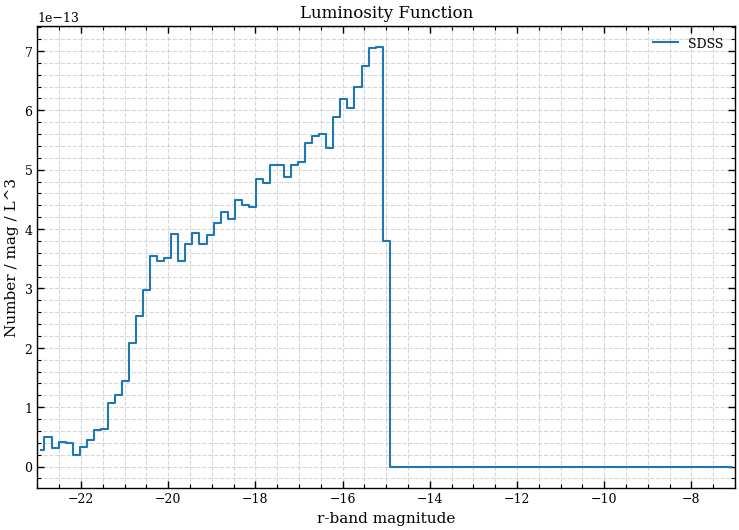

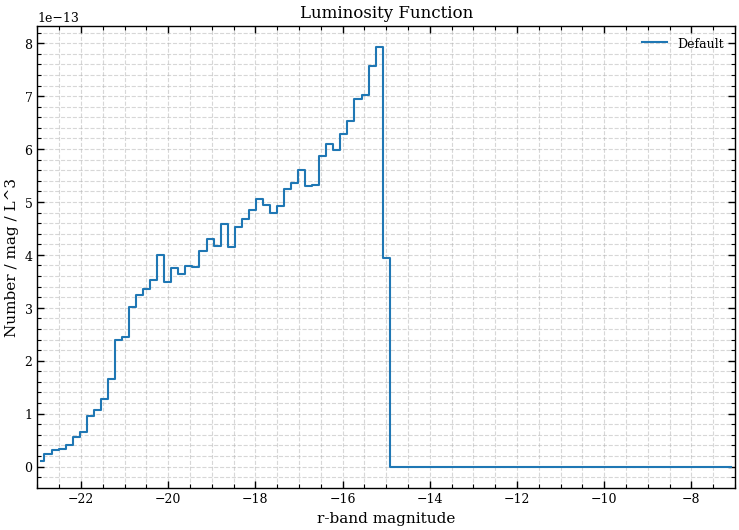

In [13]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='SDSS')

figDEFAULT, axDEFAULT = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, ax=axDEFAULT, label='Default')


(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'r-band shift'}, xlabel='r-band (SDSS - Default)', ylabel='Number'>,
 <Axes: title={'center': 'g-band shift'}, xlabel='g-band (SDSS - Default)', ylabel='Number'>)

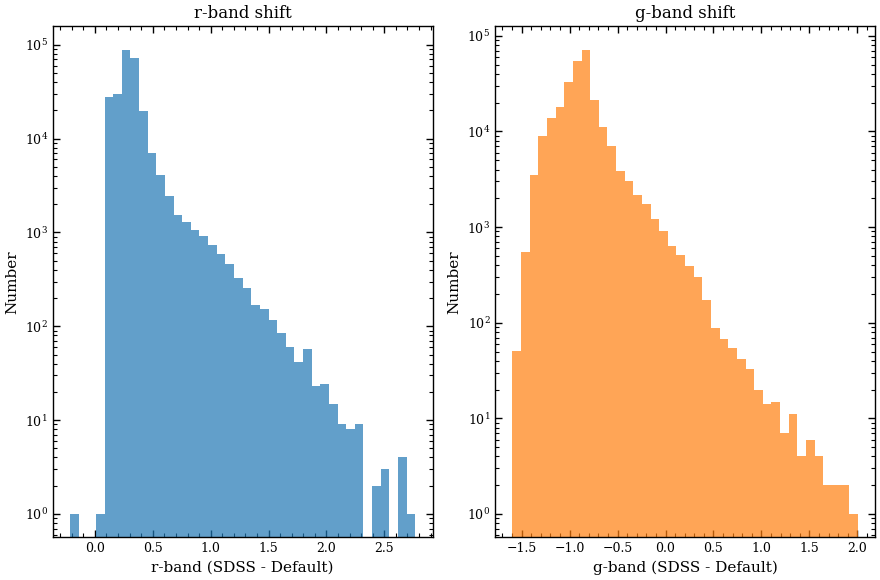

In [96]:
# see hist of how much a galaxies r and g band have shifted
def plot_shift_in_band(list_gg_sdss:ListGalaxyGroup, list_gg_default:ListGalaxyGroup, label=None, color=None):
    rmagSDSS = []
    gmagSDSS = []
    for gg in list_gg_sdss.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmagSDSS.append(galaxy.getRbandMagnitude())
            gmagSDSS.append(galaxy.getGbandMagnitude())
    rmagDefault = []
    gmagDefault = []
    for gg in list_gg_default.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmagDefault.append(galaxy.getDefaultRbandMagnitude())
            gmagDefault.append(galaxy.getDefaultGbandMagnitude())

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9,6))
    # plot histograms of the shifts
    rshift = np.array(rmagSDSS) - np.array(rmagDefault)
    gshift = np.array(gmagSDSS) - np.array(gmagDefault)

    ax1.hist(rshift, bins=40, color=color or 'C0', alpha=0.7)
    ax1.set_xlabel('r-band (SDSS - Default)')
    ax1.set_ylabel('Number')
    ax1.set_title('r-band shift')
    ax1.set_yscale('log')

    ax2.hist(gshift, bins=40, color=color or 'C1', alpha=0.7)
    ax2.set_xlabel('g-band (SDSS - Default)')
    ax2.set_ylabel('Number')
    ax2.set_title('g-band shift')
    ax2.set_yscale('log')

    fig.tight_layout()
    return fig, ax1, ax2
#for all galaxies
plot_shift_in_band(list_gg_sdss=galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw, list_gg_default=galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw)
#for cluster galaxies

In [92]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function2(list_gg:ListGalaxyGroup, list_gg2:ListGalaxyGroup, plot_dirc:str='', label=None, label2=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude())
    rmags2 = []
    for gg in list_gg2.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags2.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)


    mags2 = np.asarray(rmags2)
    hist2, edges2 = np.histogram(mags2, bins=bins)
    width2 = np.diff(edges2)
    values2 = hist2.astype(float) / width2
    if volume is not None:
        values2 = values2 / float(volume)
    centers2 = edges2[:-1] + 0.5 * width2
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers2, values2, where='mid', label=label2, color=color, **hk)

    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_yscale('log')
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

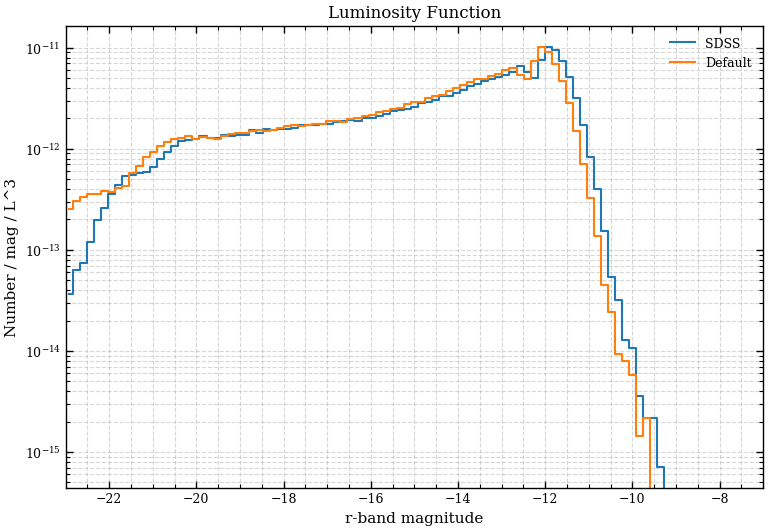

In [94]:
figBoth, axBoth = plt.subplots(figsize=(9,6))
plot_luminosity_function2(galaxyAnalysisSDSS.loaded_list_of_galaxy_groupsRaw, galaxyAnalysisDefault.loaded_list_of_galaxy_groupsRaw, ax=axBoth, label='SDSS', label2='Default')



# save file for Prof

I know this will be a huge file, but there will be room to dump it into the OneDrive folder.  Make a file where each line of the file corresponds to an individual galaxy (of cosmological origin) and the columns are: 1) x-coordinate in the database, 2) y-coordinate in the database, 3) z-coordinate in the database, 4) g-band magnitude from the supplemental catalog, 5) r-band magnitude from the supplemental catalog.  I’d like to play around with that file a bit myself to see if I can reproduce your intriguing P(Delta phi) results.  I think you have write permission for the OneDrive folder that has all the background reading info in it.  If it doesn’t allow you to write, let me know and we’ll figure out another way for me to get the file.

In [78]:
#save the SDDS's galaxy groups id, x, y, z, g, r to a txt file
with open('galaxy_groups_SDSS.txt', 'w') as f:
    f.write('group id\tid\tx\ty\tz\tg\tr\n')
    for galaxy_group in galaxyAnalysisSDSS.loaded_list_of_galaxy_groups.getAllGalaxyGroups():
        for galaxy in galaxy_group.getSubhalos():
            f.write(f"{galaxy_group.getGroupID()}\t{galaxy.getIdx()}\t{galaxy.getPosition()[0]}\t{galaxy.getPosition()[1]}\t{galaxy.getPosition()[2]}\t{galaxy.getGbandMagnitude()}\t{galaxy.getRbandMagnitude()}\n")

# check MRL

Use only the 280 most massive clusters and the original magnitudes (not the supplemental magnitudes).  From those, tell me what % of all clusters have an MRL value that is larger than that of a random sample more than 90% of the time, more than 95% of the time, more than 99% of the time, and more than 99.9% of the time.  Then, do the same thing, separately, for the small clusters (< 50 members in the original 280 clusters) and the big clusters (> 150 members).  Before we do anything else with this statistic, I want to be sure you can reproduce the results that I came up with last fall (and which I haven’t given you yet, so you don’t know the answer in advance).  


final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
lenMRL: 840, lenrandom: (280, 300000)ibution for Galaxy Group 280 / 280 with 58 satellitess


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


99th percentile MRL: 0.2732103966333875
Overall number of MRL values above 99th percentile: 84 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_99.png_TNG300-1_z0p0
final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
lenMRL: 840, lenrandom: (280, 300000)ibution for Galaxy Group 280 / 280 with 58 satellitess


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


99th percentile MRL: 0.21171478657511333
Overall number of MRL values above 99th percentile: 172 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_95.png_TNG300-1_z0p0
final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
lenMRL: 840, lenrandom: (280, 300000)ibution for Galaxy Group 280 / 280 with 58 satellitess


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


99th percentile MRL: 0.1813777921976262
Overall number of MRL values above 99th percentile: 236 out of 840
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_90.png_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with more than 150 satellites: 40
total to process: 280
Number of galaxy groups with less than 50 satellites: 35
final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
lenMRL: 120, lenrandom: (40, 300000)ribution for Galaxy Group 40 / 40 with 295 satellites
choosing ax, 0


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:247: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


99th percentile MRL: 0.15564000101350894
Overall number of MRL values above 99th percentile: 41 out of 120
lenMRL: 105, lenrandom: (35, 300000)ribution for Galaxy Group 35 / 35 with 37 satellites
choosing ax, 1
99th percentile MRL: 0.32832780606356093
Overall number of MRL values above 99th percentile: 3 out of 105
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/MRL_distribution_curves_overlay_MRLDistribution_gt14_default_99_member_difference_TNG300-1_z0p0


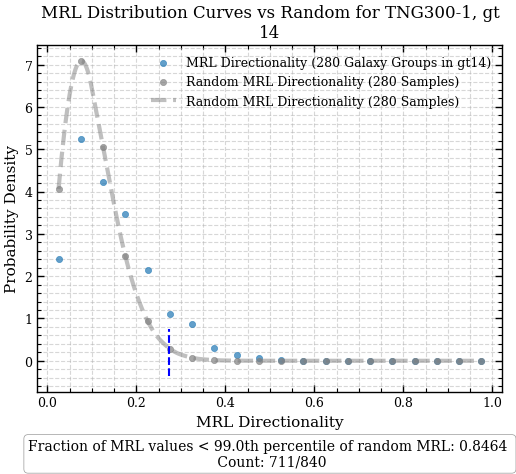

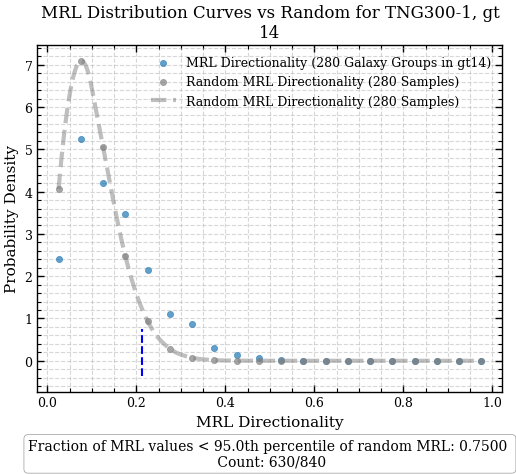

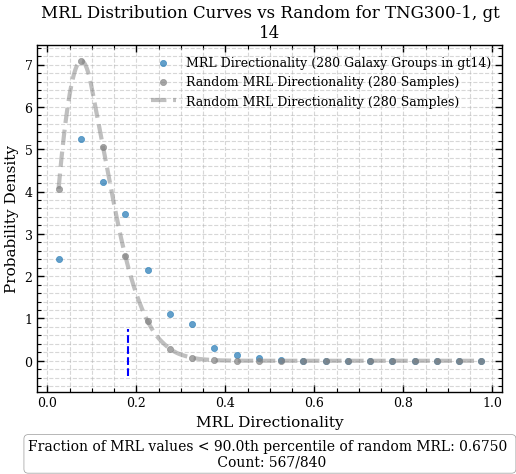

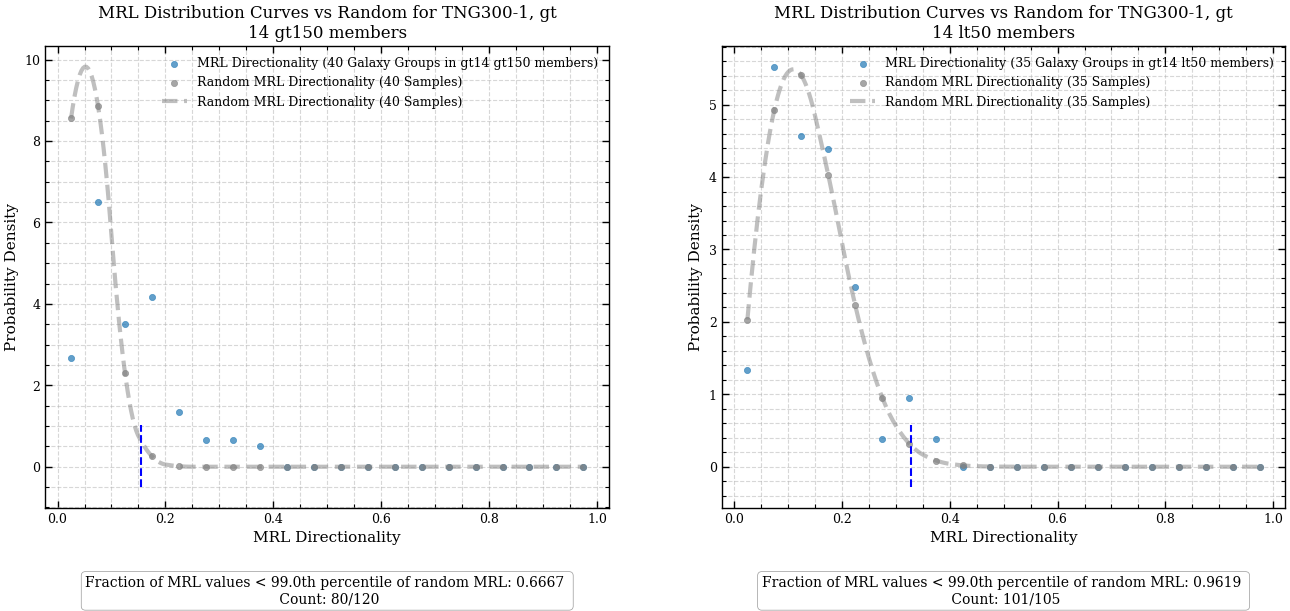

In [5]:
galaxyAnalysisDefault.setGeneralRewrite(True)
#compute MRL distribution plots for only gt14 of default
galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_99.png', percentageMRL = 0.99*100)

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_95.png', percentageMRL = 0.95*100)

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups, 'gt14')], filename='MRLDistribution_gt14_default_90.png', percentageMRL = 0.90*100)

#get gt150 members
filtered_GT150_list_of_galaxy_groups = galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(minNumGalaxies=150)
print(f'Number of galaxy groups with more than 150 satellites: {filtered_GT150_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_LT50_list_of_galaxy_groups = galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups.getFilterSubhalos(maxNumGalaxies=50)
print(f'Number of galaxy groups with less than 50 satellites: {filtered_LT50_list_of_galaxy_groups.getNumGalaxyGroups()}')

galaxyAnalysisDefault.overlayMRLAndMRLRandom([(filtered_GT150_list_of_galaxy_groups, 'gt14 gt150 members'), (filtered_LT50_list_of_galaxy_groups, 'gt14 lt50 members')], filename='MRLDistribution_gt14_default_99_member_difference', percentageMRL=0.99*100)
galaxyAnalysisDefault.setGeneralRewrite(True)

# double check p(deltaphi)

generalrewrite: True, plotidentifier: TNG300-1_z0p0
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (28, 550)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 59/59 in Galaxy Group ID 197 with total pairs 171136
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 157/157 in Galaxy Group ID 32 with total pairs 12246
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606
F

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.35222123e-03
  3.49949852e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.18642125e-03
  3.45352617e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.98742272e-03
  3.39752739e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.75933208e-03
  3.33218470e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.58034522e-03
  3.27999770e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.42528369e-03
  3.23410587e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.31151791e-03
  3.20001734e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.23043016e-03
  3.17549702e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.20193570e-03
  3.16683544e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.17062649e-03
  3.15729084e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.1837

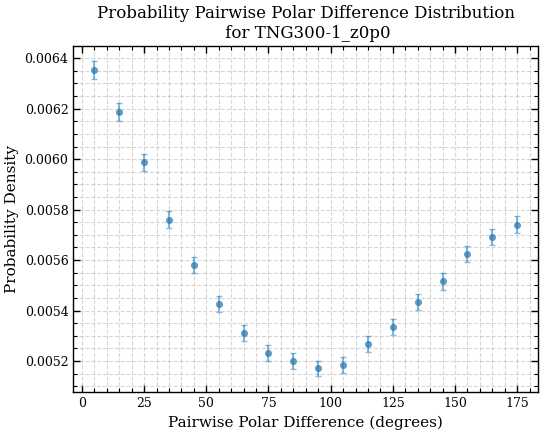

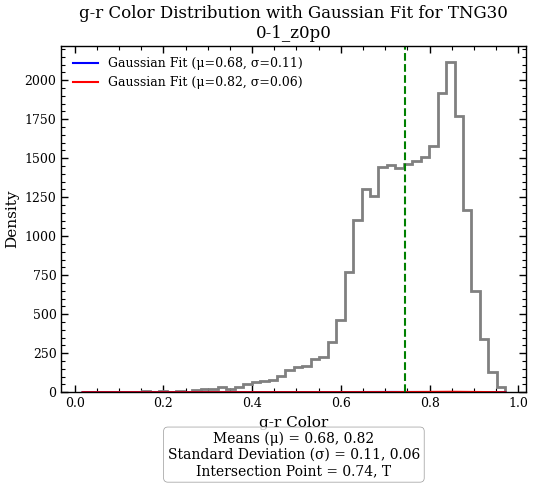

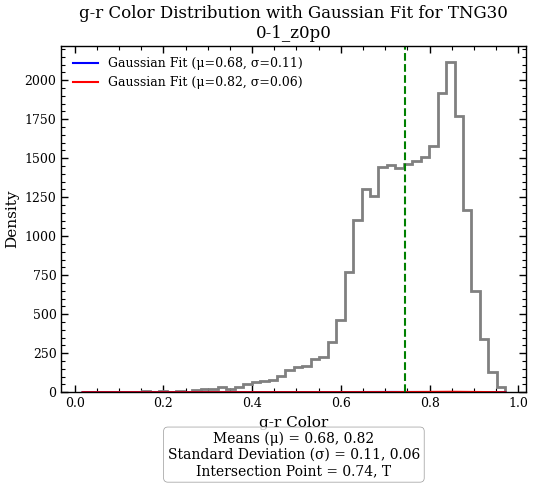

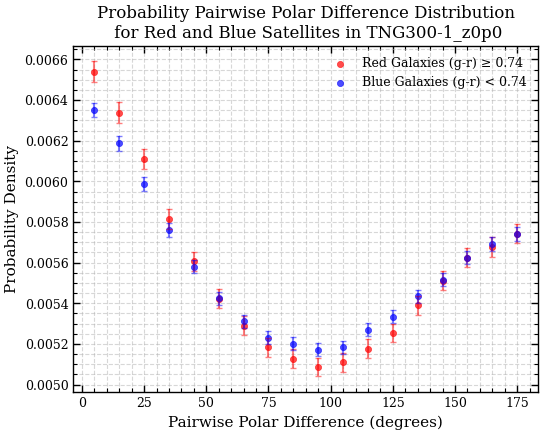

In [25]:
galaxyAnalysisSDSS.setGeneralRewrite(True)
galaxyAnalysisSDSS.pairwisePolarDifferencePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.redVsBlueDistributionPlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.redVsBluePairwisePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisSDSS.setGeneralRewrite(False)

generalrewrite: True, plotidentifier: TNG300-1_z0p0
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 2/597 in Galaxy Group ID 0 with total pairs 177906

Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (31, 597)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 66/66 in Galaxy Group ID 197 with total pairs 214528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 168/168 in Galaxy Group ID 32 with total pairs 14028
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210
F

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.33500921e-03
  3.21630432e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.18120373e-03
  3.17702065e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.98077815e-03
  3.12508875e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.76188416e-03
  3.06736720e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.58704657e-03
  3.02047089e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.42964865e-03
  2.97762068e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.31367811e-03
  2.94564991e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.23735506e-03
  2.92441846e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.20009164e-03
  2.91399637e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.18356641e-03
  2.90936253e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.1878

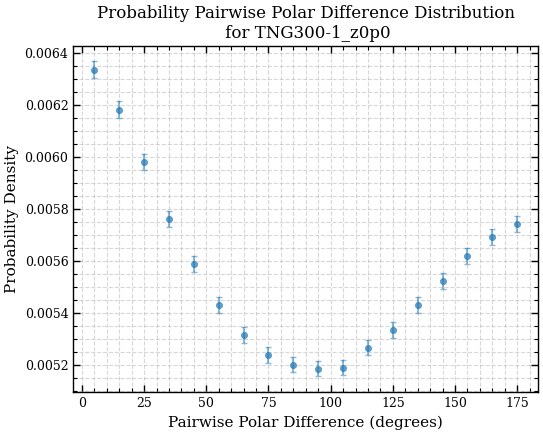

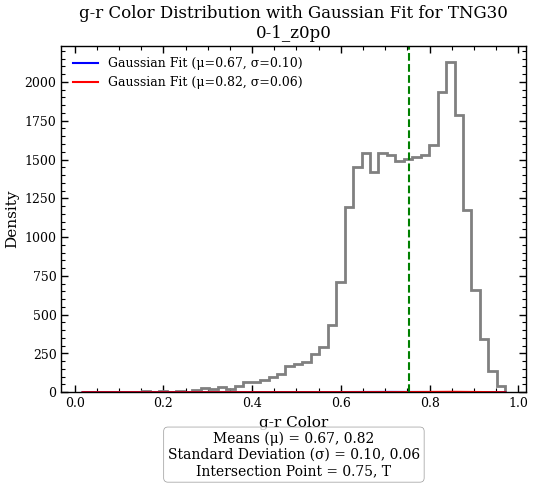

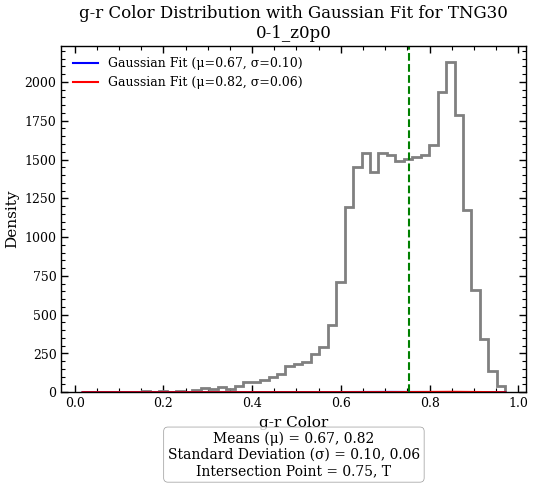

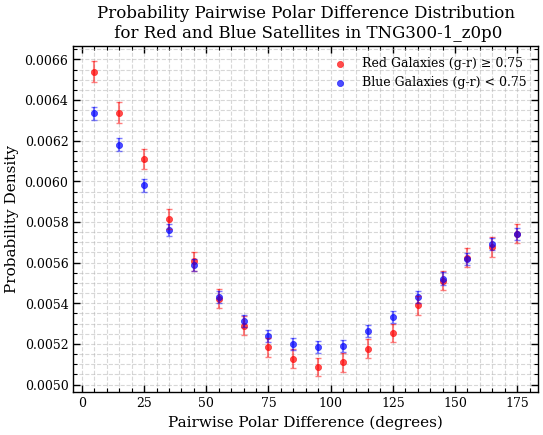

In [24]:
galaxyAnalysisDefault.setGeneralRewrite(True)
galaxyAnalysisDefault.pairwisePolarDifferencePlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisDefault.redVsBlueDistributionPlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisDefault.redVsBluePairwisePlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisDefault.setGeneralRewrite(False)

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (28, 550)
Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Computed pairwise polar differences between red and blue satellite galaxies.


<string>:58: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00            nan            nan 6.35222123e-03
  1.10663860e-05]
 [1.50000000e+01            nan            nan 6.18642125e-03
  1.09210086e-05]
 [2.50000000e+01            nan            nan 5.98742272e-03
  1.07439250e-05]
 [3.50000000e+01            nan            nan 5.75933208e-03
  1.05372933e-05]
 [4.50000000e+01            nan            nan 5.58034522e-03
  1.03722635e-05]
 [5.50000000e+01            nan            nan 5.42528369e-03
  1.02271407e-05]
 [6.50000000e+01            nan            nan 5.31151791e-03
  1.01193433e-05]
 [7.50000000e+01            nan            nan 5.23043016e-03
  1.00418033e-05]
 [8.50000000e+01            nan            nan 5.20193570e-03
  1.00144130e-05]
 [9.50000000e+01            nan            nan 5.17062649e-03
  9.98423029e-06]
 [1.05000000e+02            nan            nan 5.1837

(<myproject.utilities.plottingTools.AstroPlotter at 0x15292a28f150>,
 array([  5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95., 105.,
        115., 125., 135., 145., 155., 165., 175.]),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan]),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan]),
 array([  5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95., 105.,
        115., 125., 135., 145., 155., 165., 175.]),
 array([0.00635222, 0.00618642, 0.00598742, 0.00575933, 0.00558035,
        0.00542528, 0.00531152, 0.00523043, 0.00520194, 0.00517063,
        0.00518376, 0.0052693 , 0.00533446, 0.00543512, 0.00551555,
        0.00562484, 0.00569176, 0.00573969]),
 array([1.10663860e-05, 1.09210086e-05, 1.07439250e-05, 1.05372933e-05,
        1.03722635e-05, 1.02271407e-05, 1.01193433e-05, 1.00418033e-05,
        1.00144130e-05, 9.98423029e-06, 9.99689803e-06, 1.00790439e-0

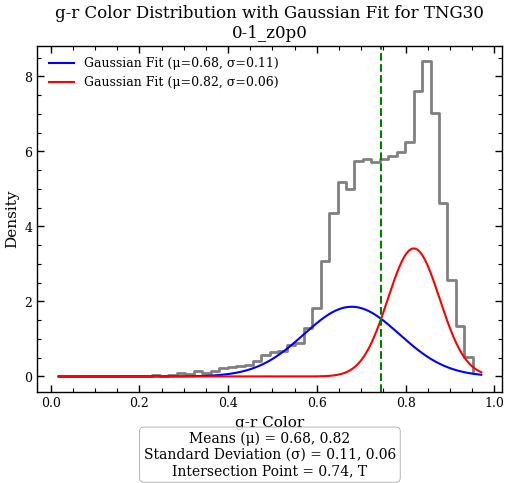

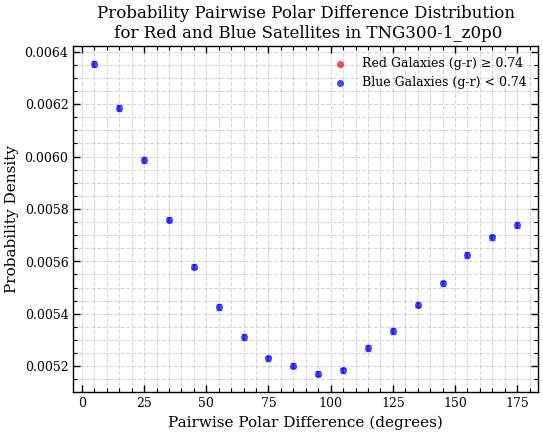

In [ ]:
galaxyAnalysisSDSS.redVsBluePairwisePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)

# overlay SDSS and default

generalrewrite: True, plotidentifier: TNG300-1_z0p0
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 38/124 in Galaxy Group ID 77 with total pairs 762650

Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210warning ax is none
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
generalrewrite: True, plotidentifier: TNG300-1_z0p0
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwisePolarDifferencePlot_overlay_SDSS_default.png


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution\n for TNG300-1, SDSS vs Default Luminosities'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

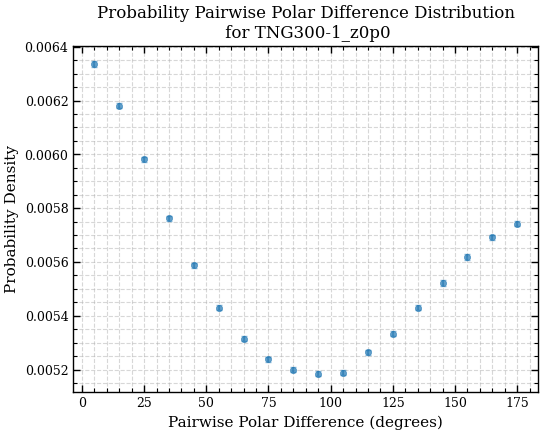

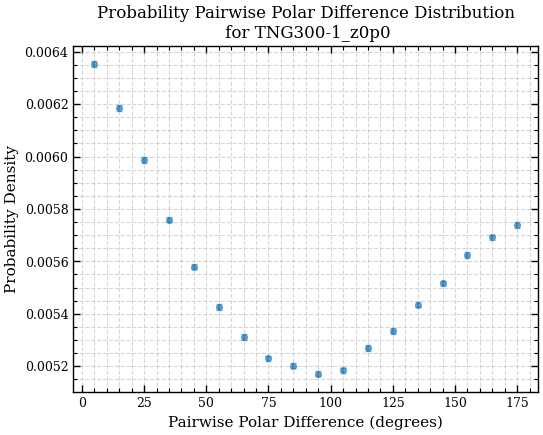

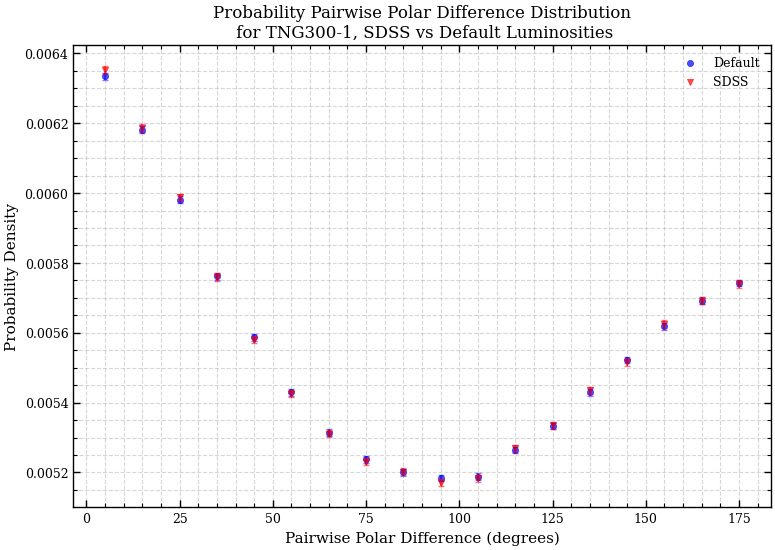

In [8]:
#overlay plots of SDSS with default for the pairwise polar difference, red vs blue distribution, and red vs blue pairwise plots
from myproject.utilities.plottingTools import AstroPlotter
galaxyAnalysisDefault.setGeneralRewrite(True)
_, polar_bin_centers, pairwise_polar_differences_binned, pairwise_polar_errorbars = galaxyAnalysisDefault.pairwisePolarDifferencePlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)#, filename='pairwisePolarDifferencePlot_overlay_default.png')
_, SDSS_polar_bin_centers, SDSS_pairwise_polar_differences_binned, SDSS_pairwise_polar_errorbars = galaxyAnalysisSDSS.pairwisePolarDifferencePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)#, filename='pairwisePolarDifferencePlot_overlay_SDSS.png')
prob_polar_plotter = AstroPlotter()
probFig, probAx = prob_polar_plotter.create_figure(figsize=(9,6))
prob_polar_plotter.scatter_plot(polar_bin_centers, pairwise_polar_differences_binned, label='Default', color='blue', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for TNG300-1, SDSS vs Default Luminosities',
            errorBars=pairwise_polar_errorbars,
            grid=True,
            ax=probAx,
            include_legend=True,
            marker='o')
prob_polar_plotter.scatter_plot(SDSS_polar_bin_centers, SDSS_pairwise_polar_differences_binned, label='SDSS', color='red', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for TNG300-1, SDSS vs Default Luminosities',
            # ylim = (0, 0.01),
            errorBars=SDSS_pairwise_polar_errorbars,
            # output_filename=self.scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_{self.plotIdentifier}{self.plotEndingFormat}' if plot_dirc is None else plot_dirc + f'/pairwise_polar_difference_{self.plotIdentifier}{self.plotEndingFormat}',
            grid=True,
            ax=probAx,
            include_legend=True,
            output_filename=scratchPlotDirc + f'/pairwisePolarDifferencePlot_overlay_SDSS_default.png',
            marker='v')


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (23, 511)
total to process: 280
Number of galaxy groups with only blue satellites: (3, 123)
Total Galaxy Groups to process: 280 with pairs : 1311672
Processing Subhalo 44/44 in Galaxy Group ID 99 with total pairs 9468208Total Galaxy Groups to process: 280 with pairs : 94644
Processing Subhalo 13/13 in Galaxy Group ID 99 with total pairs 78583Computed pairwise polar differences between red and blue satellite galaxies.


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.51457333e-03 1.29726570e-05 6.06486742e-03
  4.76898568e-05]
 [1.50000000e+01 6.31801137e-03 1.27754483e-05 5.89761763e-03
  4.70276923e-05]
 [2.50000000e+01 6.06531468e-03 1.25173563e-05 5.82336772e-03
  4.67307197e-05]
 [3.50000000e+01 5.80318901e-03 1.22438868e-05 5.66436792e-03
  4.60883425e-05]
 [4.50000000e+01 5.59006821e-03 1.20169568e-05 5.67861790e-03
  4.61462788e-05]
 [5.50000000e+01 5.39451373e-03 1.18048942e-05 5.59049301e-03
  4.57868132e-05]
 [6.50000000e+01 5.26302465e-03 1.16601369e-05 5.48849314e-03
  4.53671947e-05]
 [7.50000000e+01 5.15584426e-03 1.15407980e-05 5.47874315e-03
  4.53268807e-05]
 [8.50000000e+01 5.12918479e-03 1.15109222e-05 5.37111829e-03
  4.48794701e-05]
 [9.50000000e+01 5.08780060e-03 1.14643909e-05 5.38949326e-03
  4.49561725e-05]
 [1.05000000e+02 5.10492777e-03 1.14836711e-05 5.4517

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.51105903e-03 1.34394984e-05 6.13619158e-03
  6.38355970e-05]
 [1.50000000e+01 6.30441995e-03 1.32245168e-05 5.91239325e-03
  6.26606832e-05]
 [2.50000000e+01 6.05991507e-03 1.29655371e-05 5.81277975e-03
  6.21305793e-05]
 [3.50000000e+01 5.80001420e-03 1.26844539e-05 5.66800813e-03
  6.13519967e-05]
 [4.50000000e+01 5.58893664e-03 1.24515047e-05 5.65140588e-03
  6.12620773e-05]
 [5.50000000e+01 5.39383761e-03 1.22322452e-05 5.48604747e-03
  6.03591687e-05]
 [6.50000000e+01 5.26811761e-03 1.20888496e-05 5.55577692e-03
  6.07415499e-05]
 [7.50000000e+01 5.16234303e-03 1.19668728e-05 5.42229483e-03
  6.00074309e-05]
 [8.50000000e+01 5.13396449e-03 1.19339352e-05 5.39041851e-03
  5.98307865e-05]
 [9.50000000e+01 5.08858101e-03 1.18810710e-05 5.40303622e-03
  5.99007705e-05]
 [1.05000000e+02 5.11049601e-03 1.19066276e-05 5.3678

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwisePolarDifferencePlot_red_overlay_SDSS_default.png
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwisePolarDifferencePlot_blue_overlay_SDSS_default.png


(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution\n for Red vs Blue Satellites, SDSS vs Default Luminosities'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

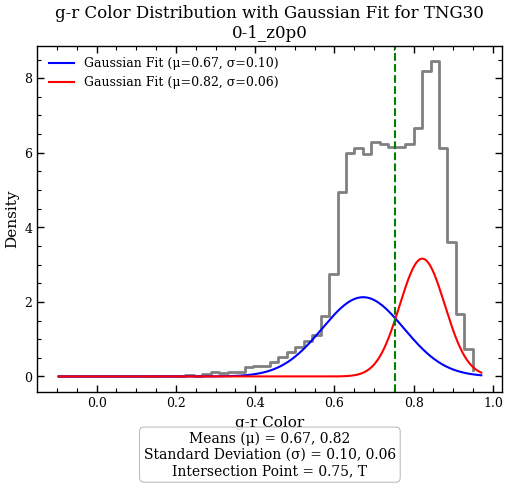

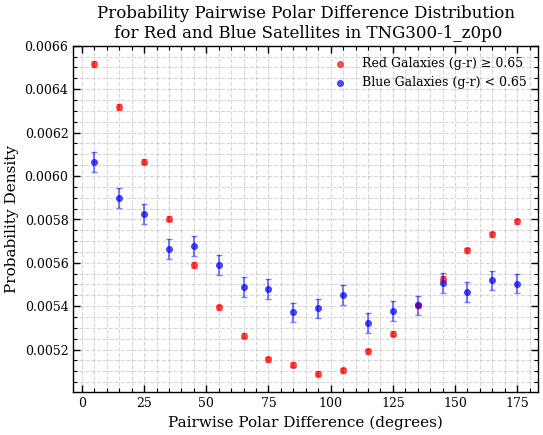

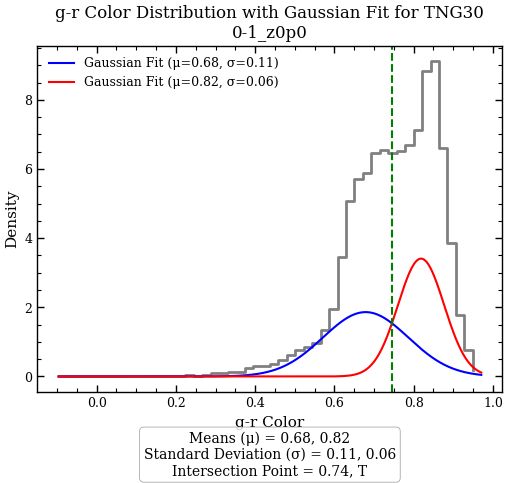

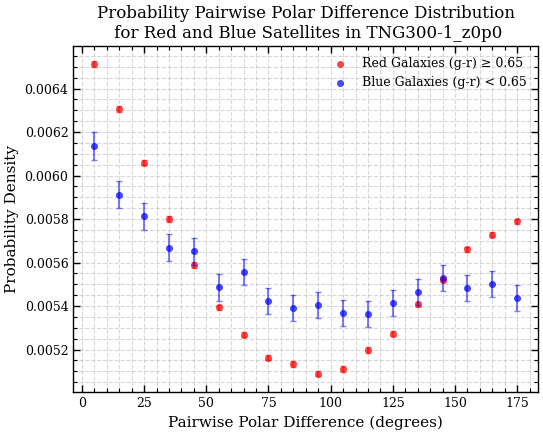

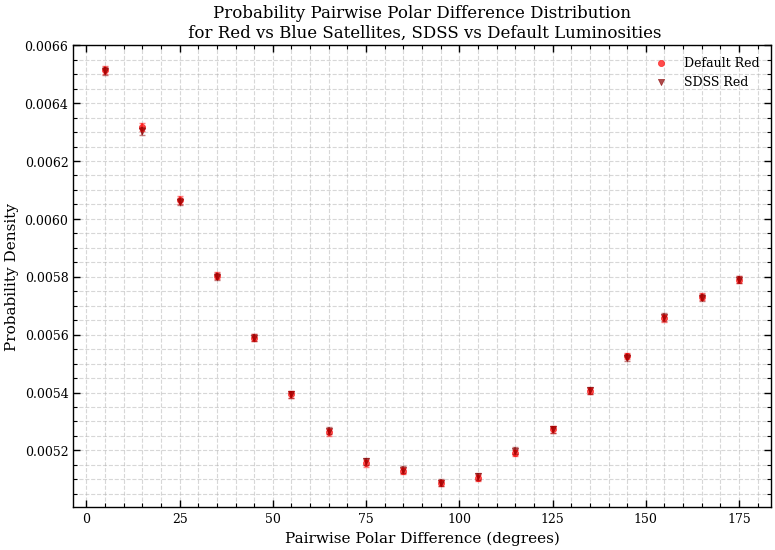

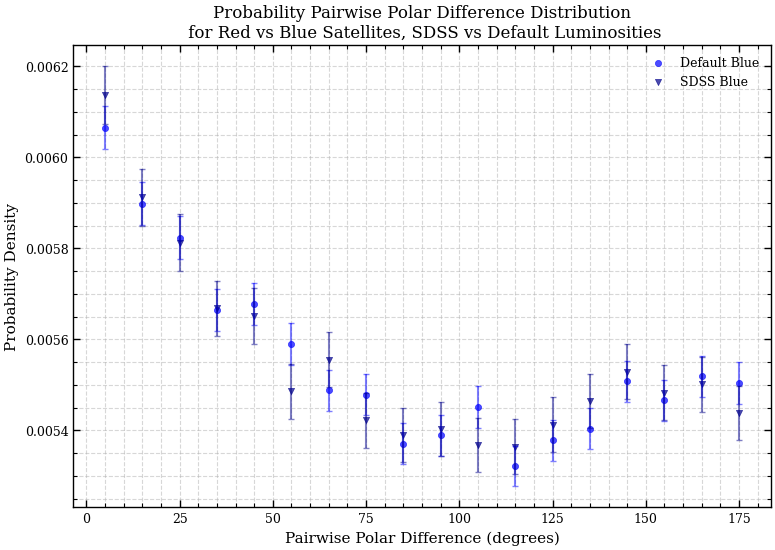

In [7]:
#overlay the red vs blue pairwise polar plot
_, polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_red_errorbars, polar_bin_centers_blue, pairwise_polar_differences_blue, pairwise_polar_blue_errorbars = galaxyAnalysisDefault.redVsBluePairwisePlot(galaxyAnalysisDefault.filtered_gt14_list_of_galaxy_groups)
_, SDSS_polar_bin_centers_red, SDSS_pairwise_polar_differences_red, SDSS_pairwise_polar_red_errorbars, SDSS_polar_bin_centers_blue, SDSS_pairwise_polar_differences_blue, SDSS_pairwise_polar_blue_errorbars = galaxyAnalysisSDSS.redVsBluePairwisePlot(galaxyAnalysisSDSS.filtered_gt14_list_of_galaxy_groups)
prob_polar_red_plotter = AstroPlotter()
probFigRed, probAxRed = prob_polar_red_plotter.create_figure(figsize=(9,6))
prob_polar_red_plotter.scatter_plot(polar_bin_centers_red, pairwise_polar_differences_red, label='Default Red', color='red', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for Red vs Blue Satellites, SDSS vs Default Luminosities',
            errorBars=pairwise_polar_red_errorbars,
            grid=True,
            ax=probAxRed,
            include_legend=True,
            marker='o')
prob_polar_red_plotter.scatter_plot(SDSS_polar_bin_centers_red, SDSS_pairwise_polar_differences_red, label='SDSS Red', color='darkred', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for Red vs Blue Satellites, SDSS vs Default Luminosities',
            errorBars=SDSS_pairwise_polar_red_errorbars,
            grid=True,
            ax=probAxRed,
            include_legend=True,
            output_filename=scratchPlotDirc + f'/pairwisePolarDifferencePlot_red_overlay_SDSS_default.png',
            marker='v')

prob_polar_blue_plotter = AstroPlotter()
probFigBlue, probAxBlue = prob_polar_blue_plotter.create_figure(figsize=(9,6))
prob_polar_blue_plotter.scatter_plot(polar_bin_centers_blue, pairwise_polar_differences_blue, label='Default Blue', color='blue', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for Red vs Blue Satellites, SDSS vs Default Luminosities',
            errorBars=pairwise_polar_blue_errorbars,
            grid=True,
            ax=probAxBlue,
            include_legend=True,
            marker='o')
prob_polar_blue_plotter.scatter_plot(SDSS_polar_bin_centers_blue, SDSS_pairwise_polar_differences_blue, label='SDSS Blue', color='darkblue', xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for Red vs Blue Satellites, SDSS vs Default Luminosities',
            errorBars=SDSS_pairwise_polar_blue_errorbars,
            grid=True,
            ax=probAxBlue,
            include_legend=True,
            output_filename=scratchPlotDirc + f'/pairwisePolarDifferencePlot_blue_overlay_SDSS_default.png',
            marker='v')

# original get galaxy data

In [4]:
galaxyAnalysisOriginal = GalaxyAnalysis(generalRewrite=True, luminosityType='Default')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [10]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 3732
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 21
 Range of satellites: (1, 597)


In [11]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 98
 Range of satellites: (31, 597)


Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210Computed pairwise polar differences between satellite galaxies.
warning ax is none
[[5.00000000e+00 6.33500921e-03 3.21630432e-05]
 [1.50000000e+01 6.18120373e-03 3.17702065e-05]
 [2.50000000e+01 5.98077815e-03 3.12508875e-05]
 [3.50000000e+01 5.76188416e-03 3.06736720e-05]
 [4.50000000e+01 5.58704657e-03 3.02047089e-05]
 [5.50000000e+01 5.42964865e-03 2.97762068e-05]
 [6.50000000e+01 5.31367811e-03 2.94564991e-05]
 [7.50000000e+01 5.23735506e-03 2.92441846e-05]
 [8.50000000e+01 5.20009164e-03 2.91399637e-05]
 [9.50000000e+01 5.18356641e-03 2.90936253e-05]
 [1.05000000e+02 5.18787734e-03 2.91057207e-05]
 [1.15000000e+02 5.26486989e-03 2.93209022e-05]
 [1.25000000e+02 5.33324058e-03 2.95106718e-05]
 [1.35000000e+02 5.42943637e-03 2.97756247e-05]
 [1.45000000e+02 5.52172945e-03 3.00276310e-05]
 [1.55000000e+02 5.61828448e-03 3.02890304e-05]
 [1.65000000e+02 5.69

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


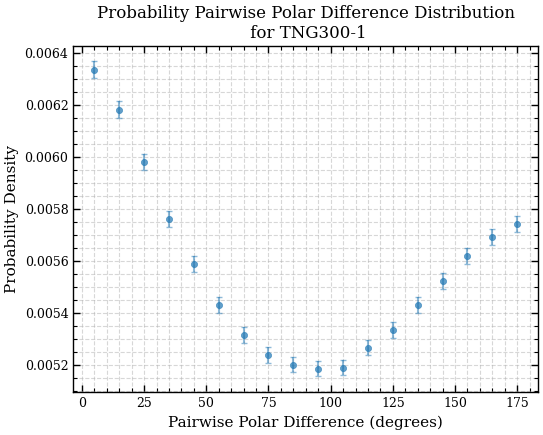

In [12]:
from myproject import GalaxyGroup, Subhalo, ListGalaxyGroup, AstroPlotter
import h5py as h5
import numpy as np
galaxyAnalysisOriginal.setGeneralRewrite(True)
list_pairwise_polar_differences_original = galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)#, tempSaveDir=f'{scratchDataDirc}/pairwise_polar', rewrite=generalRewrite)
pairwise_polar_differences_binned_original, polar_bin_centers_original, pairwise_polar_errorbars_original = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_original, bins = np.arange(0, 185, 10), errorbarType='poisson')
print('Computed pairwise polar differences between satellite galaxies.')

prob_polar_plotter = AstroPlotter()
prob_polar_plotter.scatter_plot(
    polar_bin_centers_original, 
    pairwise_polar_differences_binned_original,
    errorBars = pairwise_polar_errorbars_original,
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for TNG300-1',
    # ylim = (0, 0.01),
    # output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_{sim}.png',
    grid=True,
)

print(np.column_stack((polar_bin_centers_original, pairwise_polar_differences_binned_original, pairwise_polar_errorbars_original)))



generalrewrite: True
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 9/597 in Galaxy Group ID 0 with total pairs 177906

Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210warning ax is none
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0


(<myproject.utilities.plottingTools.AstroPlotter at 0x14ae1d317b10>,
 array([  5.,  15.,  25.,  35.,  45.,  55.,  65.,  75.,  85.,  95., 105.,
        115., 125., 135., 145., 155., 165., 175.]),
 array([0.00633501, 0.0061812 , 0.00598078, 0.00576188, 0.00558705,
        0.00542965, 0.00531368, 0.00523736, 0.00520009, 0.00518357,
        0.00518788, 0.00526487, 0.00533324, 0.00542944, 0.00552173,
        0.00561828, 0.00569206, 0.00574224]),
 array([3.21630432e-05, 3.17702065e-05, 3.12508875e-05, 3.06736720e-05,
        3.02047089e-05, 2.97762068e-05, 2.94564991e-05, 2.92441846e-05,
        2.91399637e-05, 2.90936253e-05, 2.91057207e-05, 2.93209022e-05,
        2.95106718e-05, 2.97756247e-05, 3.00276310e-05, 3.02890304e-05,
        3.04872498e-05, 3.06213392e-05]))

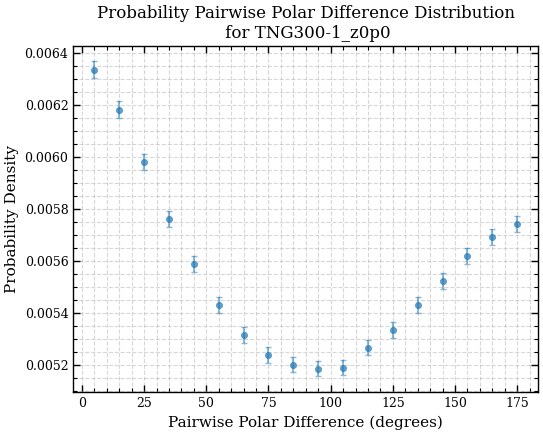

In [13]:
galaxyAnalysisOriginal.setGeneralRewrite(True)
galaxyAnalysisOriginal.pairwisePolarDifferencePlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)


Total Galaxy Groups to process: 3732 with pairs : 2549893
Processing Subhalo 15/15 in Galaxy Group ID 1087 with total pairs 10528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 15/15 in Galaxy Group ID 1177 with total pairs 10550
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1267 with total pairs 91678
Intermediate save after processing 300 galaxy groups.
Processing Subhalo 17/17 in Galaxy Group ID 1359 with total pairs 13678
Intermediate save after processing 400 galaxy groups.
Processing Subhalo 9/9 in Galaxy Group ID 1449 with total pairs 3691590
Intermediate save after processing 500 galaxy groups.
Processing Subhalo 10/10 in Galaxy Group ID 1540 with total pairs 45000
Intermediate save after processing 600 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1633 with total pairs 91645
Intermediate save after processing 700 galaxy groups.
Processing Subhalo 14/14 in Galaxy Group ID 1723 with total 

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
total to process: 280
Number of galaxy groups with only red satellites: (0, 0)
total to process: 280
Number of galaxy groups with only blue satellites: (31, 597)
Total Galaxy Groups to process: 0 with pairs : 0

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 2068402
Processing Subhalo 66/66 in Galaxy Group ID 197 with total pairs 214528
Intermediate save after processing 100 galaxy groups.
Processing Subhalo 168/168 in Galaxy Group ID 32 with total pairs 14028
Intermediate save after processing 200 galaxy groups.
Processing Subhalo 57/57 in Galaxy Group ID 99 with total pairs 1596210
F

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1_z0p0
data to be saved: [[5.00000000e+00 6.53907745e-03 5.11330653e-05 6.33500921e-03
  3.21630432e-05]
 [1.50000000e+01 6.33831735e-03 5.03420131e-05 6.18120373e-03
  3.17702065e-05]
 [2.50000000e+01 6.10792904e-03 4.94186162e-05 5.98077815e-03
  3.12508875e-05]
 [3.50000000e+01 5.81580531e-03 4.82223663e-05 5.76188416e-03
  3.06736720e-05]
 [4.50000000e+01 5.60632868e-03 4.73459534e-05 5.58704657e-03
  3.02047089e-05]
 [5.50000000e+01 5.42156222e-03 4.65592324e-05 5.42964865e-03
  2.97762068e-05]
 [6.50000000e+01 5.28973469e-03 4.59896954e-05 5.31367811e-03
  2.94564991e-05]
 [7.50000000e+01 5.18341700e-03 4.55251791e-05 5.23735506e-03
  2.92441846e-05]
 [8.50000000e+01 5.12743928e-03 4.52786898e-05 5.20009164e-03
  2.91399637e-05]
 [9.50000000e+01 5.08493620e-03 4.50906340e-05 5.18356641e-03
  2.90936253e-05]
 [1.05000000e+02 5.10884668e-03 4.51965227e-05 5.1878

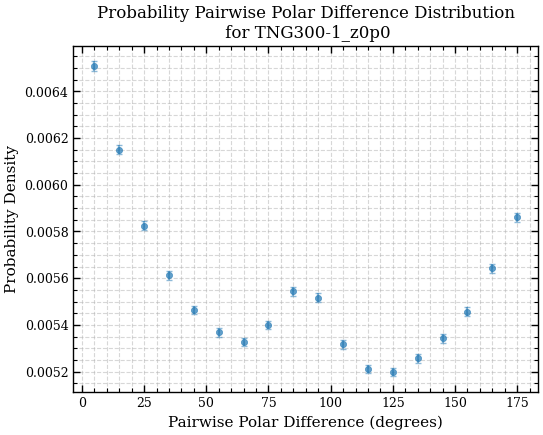

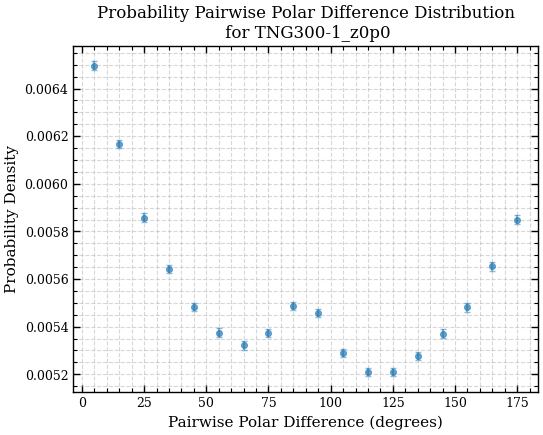

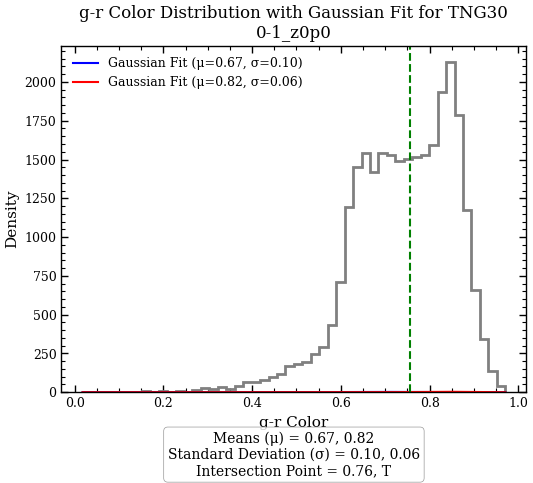

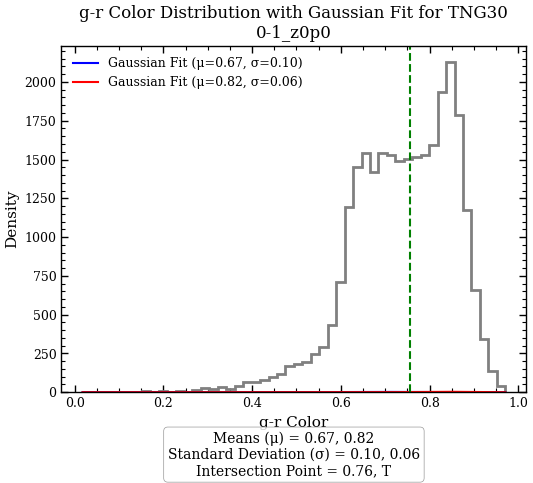

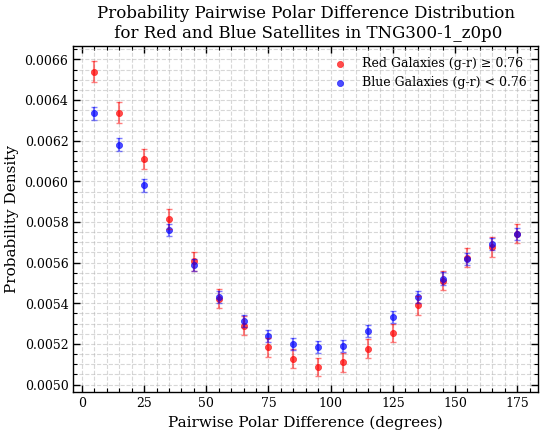

In [17]:
galaxyAnalysisOriginal.setGeneralRewrite(True)
galaxyAnalysisOriginal.pairwisePolarDifferencePlot(galaxyAnalysisOriginal.loaded_list_of_galaxy_groupsRaw)
galaxyAnalysisOriginal.pairwisePolarDifferencePlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.redVsBlueDistributionPlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.redVsBluePairwisePlot(galaxyAnalysisOriginal.filtered_gt14_list_of_galaxy_groups)
galaxyAnalysisOriginal.setGeneralRewrite(False)

# check color distributions on all objects

In [11]:
# check color distributions on all objects
#load from datacatalog scratchDataDirc + 'catalogs/SubhaloStellarPhotometrics'
#default from datacatalog scratchDataDirc + 'catalogs/SubhaloStellarPhotometrics/SubhaloStellarPhotometricsDefault'
import h5py
import numpy as np
photometrics = []
photometricsSDSS = []
SDSSfilename = scratchDataDirc + 'catalogs/SubhaloStellarPhotometrics/SubhaloStellarPhotometrics'
defaultfilename = scratchDataDirc + 'catalogs/SubhaloStellarPhotometrics/SubhaloStellarPhotometricsDefault'

SDSSdatafile = SDSSfilename + '.hdf5'
defaultfile = defaultfilename + '.hdf5'
with h5py.File(SDSSdatafile,'r') as f:
    print(f.keys())
    SubhaloStellarPhotometricsSDSSFull=f['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc'][:]
    print(SubhaloStellarPhotometricsSDSSFull.shape)
    # print(SubhaloStellarPhotometrics[0:5,:])
    # print(SubhaloVmaxRad.shape)
SubhaloStellarPhotometricsSDSS = []
for sdss in SubhaloStellarPhotometricsSDSSFull:
    SubhaloStellarPhotometricsSDSS.append((sdss[0][0], sdss[1][0], sdss[2][0], sdss[3][0],sdss[4][0],sdss[5][0],sdss[6][0],sdss[7][0]))
photometricsSDSS = np.array(SubhaloStellarPhotometricsSDSS)
    
with h5py.File(defaultfile,'r') as f:
    photometrics=np.array(f['Subhalo']['SubhaloStellarPhotometrics'])

<KeysViewHDF5 ['Subhalo_StellarPhot_p07c_cf00dust_res_conv_ns1_rad30pkpc', 'subhaloIDs']>
(14485709, 8, 12)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/color_distribution_TNG300-1_z0p0


(np.float32(0.451179), True)

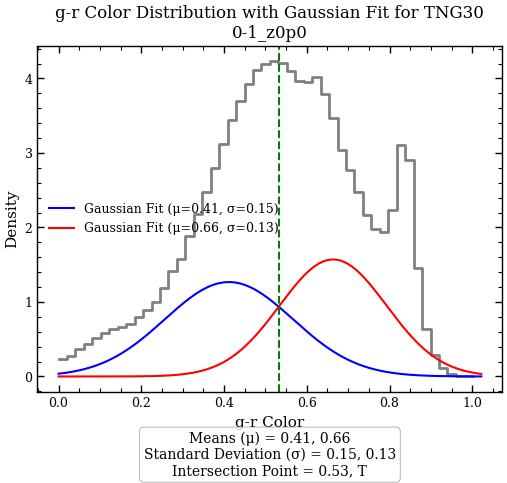

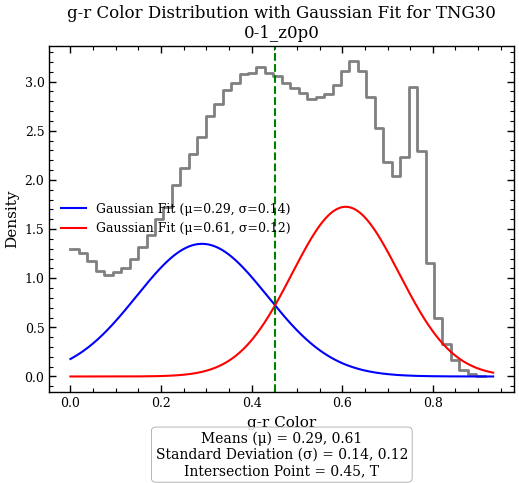

In [13]:
galaxyAnalysisSDSS.redVsBlueDistributionPlot(list_photometrics=photometricsSDSS)
galaxyAnalysisDefault.redVsBlueDistributionPlot(list_photometrics=photometrics)

# TBD...